# Fitting a linear regression model


## Fit a linear regression model on a dataset with one feature

In [ ]:
import numpy as np
# sklearn is a python package for machine learning
from sklearn.linear_model import LinearRegression

X = np.array([[0], [1], [2], [3], [4], [5], [6], [7]])
y = np.array([0, 2, 4, 6, 10, 8, 12, 14])
fitted_model = LinearRegression().fit(X, y)
sum_of_squares_error = sum((fitted_model.predict(X) - y) ** 2)
sum_of_squares_error

np.float64(7.904761904761901)

In [ ]:
fitted_model.intercept_

np.float64(0.16666666666666252)

In [ ]:
fitted_model.coef_[0]

np.float64(1.9523809523809534)

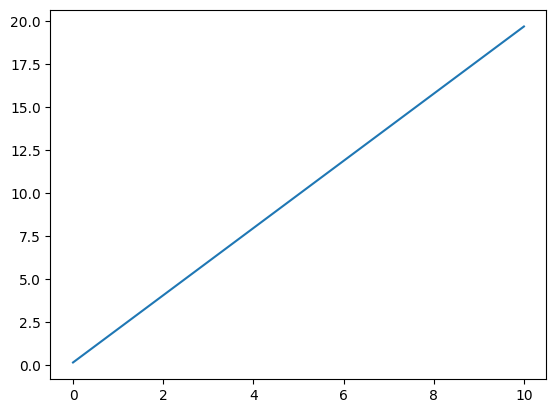

In [ ]:
import matplotlib.pyplot as plt
x_grid = np.linspace(0, 10, num=100)
plt.plot(x_grid, fitted_model.intercept_ + x_grid * fitted_model.coef_[0])
plt.show()

## Fitting a real dataset with three features

In [ ]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head() # https://www.amnh.org/learn-teach/curriculum-collections/biodiversity-counts/plant-identification/plant-morphology/parts-of-a-flower

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
data = iris.to_numpy() # Converting the data into a numpy array

In [ ]:
X = data[0:,1:4] # remove species column as it is not an real number
X

array([[3.5, 1.4, 0.2],
       [3.0, 1.4, 0.2],
       [3.2, 1.3, 0.2],
       [3.1, 1.5, 0.2],
       [3.6, 1.4, 0.2],
       [3.9, 1.7, 0.4],
       [3.4, 1.4, 0.3],
       [3.4, 1.5, 0.2],
       [2.9, 1.4, 0.2],
       [3.1, 1.5, 0.1],
       [3.7, 1.5, 0.2],
       [3.4, 1.6, 0.2],
       [3.0, 1.4, 0.1],
       [3.0, 1.1, 0.1],
       [4.0, 1.2, 0.2],
       [4.4, 1.5, 0.4],
       [3.9, 1.3, 0.4],
       [3.5, 1.4, 0.3],
       [3.8, 1.7, 0.3],
       [3.8, 1.5, 0.3],
       [3.4, 1.7, 0.2],
       [3.7, 1.5, 0.4],
       [3.6, 1.0, 0.2],
       [3.3, 1.7, 0.5],
       [3.4, 1.9, 0.2],
       [3.0, 1.6, 0.2],
       [3.4, 1.6, 0.4],
       [3.5, 1.5, 0.2],
       [3.4, 1.4, 0.2],
       [3.2, 1.6, 0.2],
       [3.1, 1.6, 0.2],
       [3.4, 1.5, 0.4],
       [4.1, 1.5, 0.1],
       [4.2, 1.4, 0.2],
       [3.1, 1.5, 0.2],
       [3.2, 1.2, 0.2],
       [3.5, 1.3, 0.2],
       [3.6, 1.4, 0.1],
       [3.0, 1.3, 0.2],
       [3.4, 1.5, 0.2],
       [3.5, 1.3, 0.3],
       [2.3, 1.3

In [ ]:
y = data[0:,0] # we want to predict sepal length based on the other features

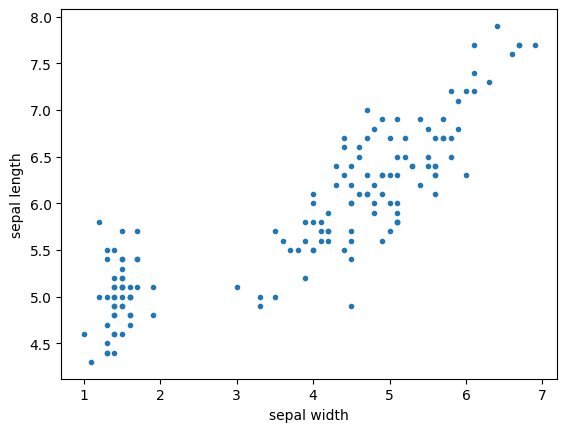

In [ ]:
# explore the data
import matplotlib.pyplot as plt
x_grid = np.linspace(0, 10, num=100)
plt.plot(X[:,1], y, ".")
plt.xlabel("sepal width")
plt.ylabel("sepal length")
plt.show()

In [ ]:
# fit linear regression model to whole dataset
fitted_model = LinearRegression().fit(X, y)
sum_of_squares_error = sum((fitted_model.predict(X) - y) ** 2)
sum_of_squares_error

14.445404913691092

In [ ]:
fitted_model.intercept_

np.float64(1.855997492917544)

In [ ]:
fitted_model.coef_

array([ 0.65083716,  0.70913196, -0.55648266])

# Test-train split

In [ ]:
nrow = X.shape[0] # number of data points
nrow

150

In [ ]:
import math
training_set_size = math.floor(0.8 * nrow)
training_set_size

120

In [ ]:
import random
random.seed(1) # this makes randomness repeatible
train_indicies = random.sample(range(nrow), training_set_size)
train_indicies[1:10] # show a few of the indicies

[145, 16, 65, 30, 126, 115, 120, 97, 53]

In [ ]:
test_indicies = list(range(nrow))
for i in train_indicies:
  test_indicies.remove(i)
len(test_indicies)

30

In [ ]:
X_train = X[train_indicies,:]
X_test = X[test_indicies,:]

In [ ]:
y_train = y[train_indicies]
y_test = y[test_indicies]

In [ ]:
# fit linear regression model to *training set*
def MSE(prediction_errors): # mean squared error
  return sum(prediction_errors ** 2)/len(prediction_errors)
fitted_model = LinearRegression().fit(X_train, y_train)
train_error = MSE(fitted_model.predict(X_train) - y_train)
test_error = MSE(fitted_model.predict(X_test) - y_test)

In [ ]:
train_error

0.09447984924412137

In [ ]:
test_error

0.10586402000361463

# Evaluating model performance

In [ ]:
# add random features to dataset
random_data = np.random.rand(X.shape[0], 110) # 110 random features to the dataset
X_with_random_data = np.concatenate((X, random_data), axis=1)
X_with_random_data.shape

(150, 113)

In [ ]:
X_with_random_data_train = X_with_random_data[train_indicies,:]
X_with_random_data_test = X_with_random_data[test_indicies,:]

In [ ]:
fitted_model_with_random_data = LinearRegression().fit(X_with_random_data_train, y_train)
train_error_with_random_data = MSE(fitted_model_with_random_data.predict(X_with_random_data_train) - y_train)
test_error_with_random_data = MSE(fitted_model_with_random_data.predict(X_with_random_data_test) - y_test)

In [ ]:
train_error_with_random_data

0.006988472432882539

In [ ]:
test_error_with_random_data

1.1682878559693537

Which model is better: fitted_model or fitted_model_with_random_data?